In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time 

In [2]:
os.system("scripts/compile_project.sh 100 100 500 1.0 1.0 1.0 > compilation.log 2>&1")
with open("compilation.log") as f:
    print(f.read())


Current directory: /home/alexr/MLMC-Proton-Therapy
Updated simulation_constants.hpp successfully.
Building project...
[  7%] Building CXX object CMakeFiles/mlmc_core.dir/src/grids.cpp.o
[ 15%] Building CXX object CMakeFiles/mlmc_core.dir/src/kinematics.cpp.o
[ 23%] Building CXX object CMakeFiles/mlmc_core.dir/src/particles.cpp.o
[ 30%] Building CXX object CMakeFiles/mlmc_core.dir/src/pencilbeam.cpp.o
[ 38%] Building CXX object CMakeFiles/mlmc_core.dir/src/simulation.cpp.o
[ 46%] Building CXX object CMakeFiles/mlmc_core.dir/src/voxeltraversal.cpp.o
[ 53%] Building CXX object CMakeFiles/mlmc_core.dir/src/treatmentplan.cpp.o
[ 61%] Linking CXX static library libmlmc_core.a
[ 69%] Built target mlmc_core
[ 76%] Building CXX object CMakeFiles/mlmcprotons.dir/src/bindings.cpp.o
[ 84%] Linking CXX shared module mlmcprotons.so
[ 84%] Built target mlmcprotons
[ 92%] Building CXX object CMakeFiles/MLCM_PROTON_BEAM.dir/src/main.cpp.o
[100%] Linking CXX executable MLCM_PROTON_BEAM
[100%] Built targ

In [3]:
# Add the relative path to the build directory
sys.path.insert(0, os.path.join(os.getcwd(), 'build'))

#import mlmcprotons
from mlmcprotons import MLMCprotons

### Initial Dose Distribution

Execution time: 6.638806 seconds


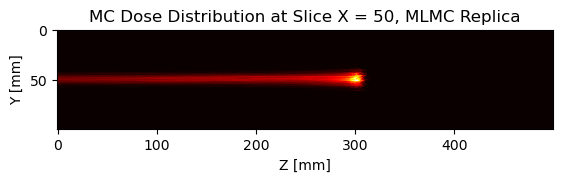

In [4]:
seed = 42
conversionTable = "HU2materialWater.csv"
phantom = "phantom.dat"
maxNumthreads = 16
miniStepShift = 1e-6        # Can not have integer step sizes
nPrim = int(1e4)
initialStep = 0.250050001
entranceDir = 'z'
beamWidth = 3.0
dir_x = 0.0
dir_y = 0.0
dir_z = 1.0
x_0 = 50.0
y_0 = 50.0
z_0 = 0.0
E = 230.0
spreadE = E/100
alpha = 0.25

start = time.time()

protonSim = MLMCprotons(seed, conversionTable)
protonSim.loadPhantom(phantom, 100, 100, 500)
protonSim.addTreatmentPlan(0)
protonSim.addPencilBeam(0, 1.0, initialStep, entranceDir, beamWidth,
    dir_x, dir_y, dir_z, x_0, y_0, z_0, E, spreadE, alpha)
protonSim.simulateTreatmentPlan(0, nPrim, maxNumthreads)
protonSim.renderCombinedScoringGrid()

end = time.time()

print(f"Execution time: {end - start:.6f} seconds")

dose = protonSim.yieldDoseAtLevel(0).grid
doseSlice = dose[50,:,:]

# Plotting the dose slice
plt.imshow(doseSlice, cmap='hot', interpolation='nearest')
plt.title(f'MC Dose Distribution at Slice X = {50}, MLMC Replica')
plt.xlabel('Z [mm]')
plt.ylabel('Y [mm]')
plt.show()

In [5]:

protonSim.yieldTotalDoseVarianceAtLevel(0)

19.368560791015625

In [ ]:
seed = 42
conversionTable = "HU2materialWater.csv"
phantom = "phantom.dat"
maxNumthreads = 16
miniStepShift = 1e-6        # Can not have integer step sizes
nPrim = int(1e4)
initialStep = 0.250050001
entranceDir = 'z'
beamWidth = 3.0
dir_x = 0.0
dir_y = 0.0
dir_z = 1.0
x_0 = 50.0
y_0 = 50.0
z_0 = 0.0
E = 230.0
spreadE = E/100
alpha = 0.25

seeds = [42, 87, 93, 133, 156, 278, 337, 423, 571, 697]

start = time.time()

for i, seed in enumerate(seeds): 

    protonSim = MLMCprotons(seed, conversionTable)
    protonSim.loadPhantom(phantom, 100, 100, 500)
    protonSim.addTreatmentPlan(0)
    protonSim.addPencilBeam(0, 1.0, initialStep, entranceDir, beamWidth,
        dir_x, dir_y, dir_z, x_0, y_0, z_0, E, spreadE, alpha)
    protonSim.simulateTreatmentPlan(0, nPrim, maxNumthreads)
    # protonSim.renderCombinedScoringGrid()

    var = protonSim.yieldTotalDoseVarianceAtLevel(0)
    print(f"{i}, Var = {var}")


end = time.time()

print(f"Execution time: {end - start:.6f} seconds")

